In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import gzip
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import time
import glob
import warnings
import numpy as np
import pandas as pd
import re

from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.table import Table
from astropy.wcs import FITSFixedWarning
from astropy import units as u
from scipy import ndimage
from skimage import restoration

import euclid_psf as ep
import clipping

sys.path.insert(0, '/home/eaev/mer_psf/')
from mer.psf.MerCatalogPsf import MerCatalogPsf as mpsf

In [3]:
jwst_cutouts, nisp_cutouts = clipping.process_all('cosmos', 'NISP-Y', redo_clips=True)

Matched catalog file ../catalog/matched_cat_cosmos_2.csv exists; not re-running.
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from 

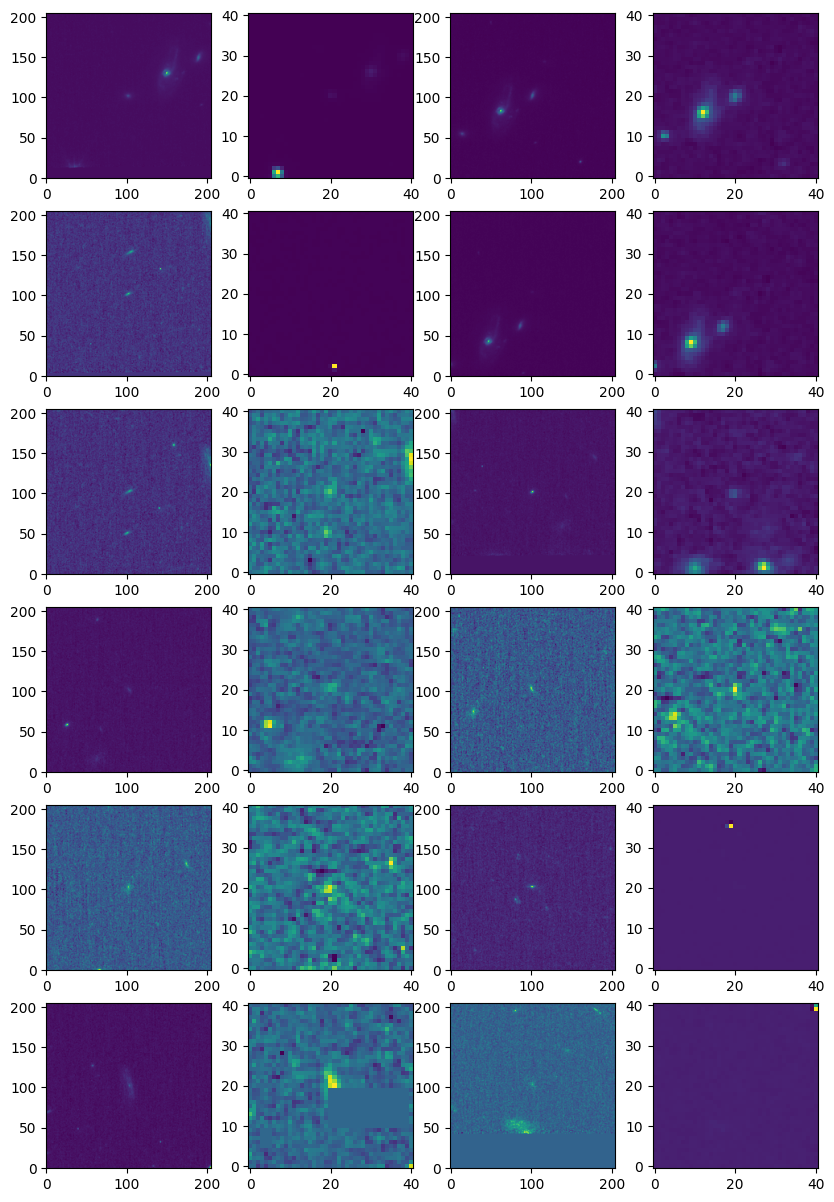

In [48]:
# Plotting images for verification purposes
n_rows = 6
fig, axes = plt.subplots(n_rows, 4, figsize=(10,2.5*n_rows))
for i in range(n_rows*2):
    clip_jwst = jwst_cutouts[i]
    clip_nisp = nisp_cutouts[i]
    axes.flatten()[i*2].imshow(clip_jwst, origin='lower')
    axes.flatten()[i*2+1].imshow(clip_nisp, origin='lower')
# plt.savefig("../plots/euclid_nisp_matches.png", bbox_inches='tight')

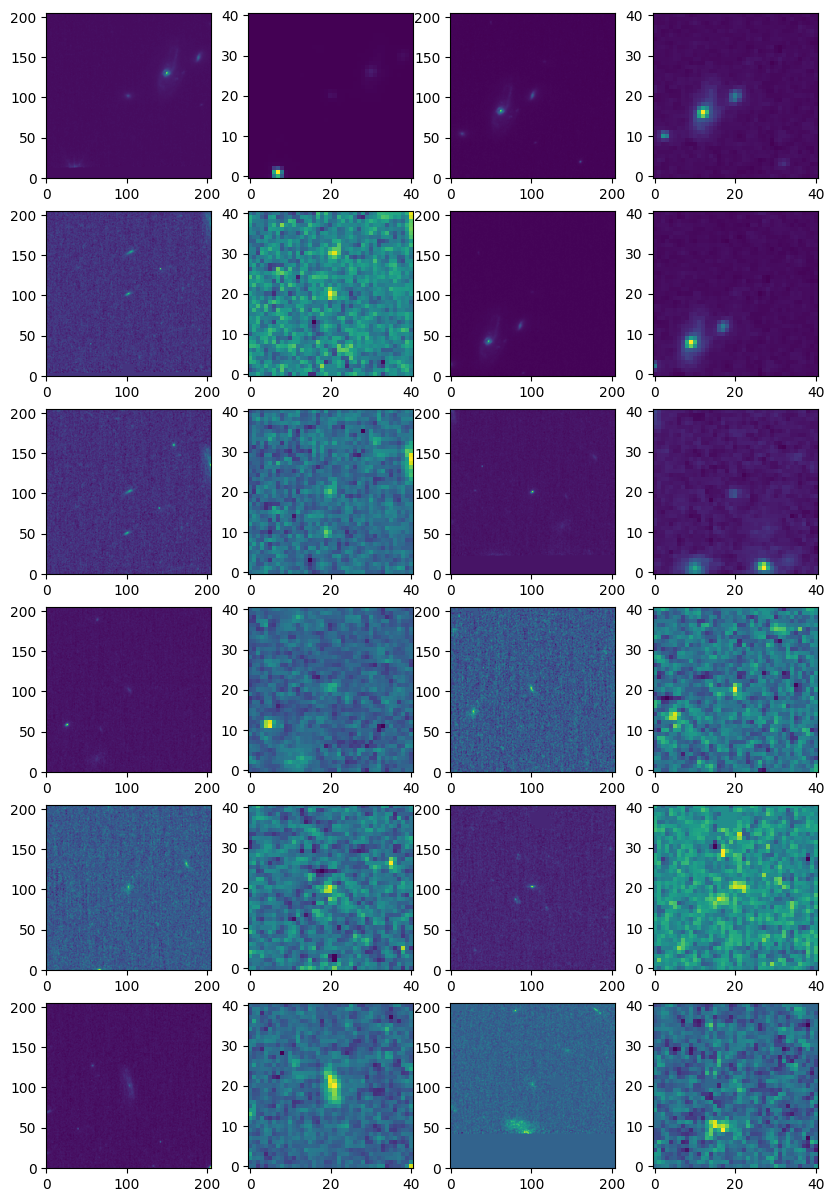

In [4]:
# Plotting images for verification purposes
n_rows = 6
fig, axes = plt.subplots(n_rows, 4, figsize=(10,2.5*n_rows))
for i in range(n_rows*2):
    clip_jwst = jwst_cutouts[i]
    clip_nisp = nisp_cutouts[i]
    axes.flatten()[i*2].imshow(clip_jwst, origin='lower')
    axes.flatten()[i*2+1].imshow(clip_nisp, origin='lower')
# plt.savefig("../plots/euclid_nisp_matches.png", bbox_inches='tight')

# Processing Euclid PSF file

In [3]:
import os
import sys
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import time
import glob
import warnings
import numpy as np
import scipy
import pandas as pd
from importlib import reload
# 
from astropy.wcs import WCS
from astropy.nddata import NDData
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.table import Table
from astropy.wcs import FITSFixedWarning
from astropy import units as u
from scipy import ndimage
from photutils.psf import GriddedPSFModel
from reproject import reproject_interp
from skimage import restoration

sys.path.insert(0, '/home/eaev/mer_psf/')
from mer.psf.MerCatalogPsf import MerCatalogPsf as mpsf
import clipping

In [4]:
# Instantiate dropbox token
with open('../../secrets/dropbox_token') as token_file:
    token = token_file.read()
    dbx = dropbox.Dropbox(token.strip(), timeout=None)

cat = pd.read_csv("../catalog/matched_cat_cosmos_2.csv")
idx = 15

file = cat.iloc[idx].nisp_image

hdr, data = clipping.get_fits_file(clipping.dbx_url, file, dbx, hdu_idx=1)
mask_hdr, mask_data = clipping.get_fits_file(clipping.dbx_url, file, dbx, hdu_idx=2)
wcs = WCS(hdr)
mask_wcs = WCS(mask_hdr)

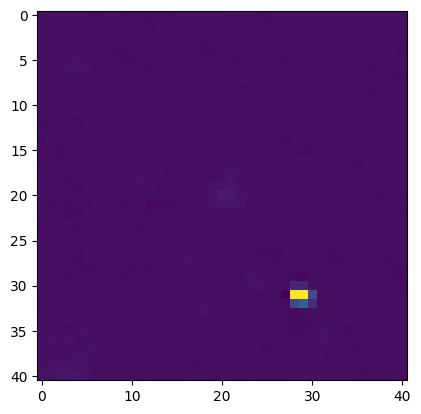

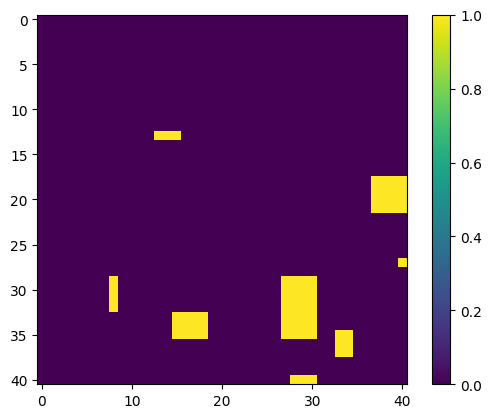

In [76]:
idx=17
ra, dec = cat.iloc[idx].ra, cat.iloc[idx].dec
sc = SkyCoord(ra, dec, unit="degree")

clip = Cutout2D(data, sc, size=41, wcs=wcs, mode='trim')
mask = Cutout2D(mask_data, sc, size=41, wcs=mask_wcs, mode='trim')
mask = (mask.data>=1)

# zoom_factor=4.37
# new_mask = ndimage.zoom(mask, zoom_factor, order=0, grid_mode=True)
plt.imshow(clip.data)
plt.show()
plt.imshow(mask)
plt.colorbar()
# plt.imshow(mask[35:38,30:35])
# plt.show()
# plt.imshow(new_mask[int(35*zoom_factor):int(38*zoom_factor),int(30*zoom_factor):int(35*zoom_factor)])

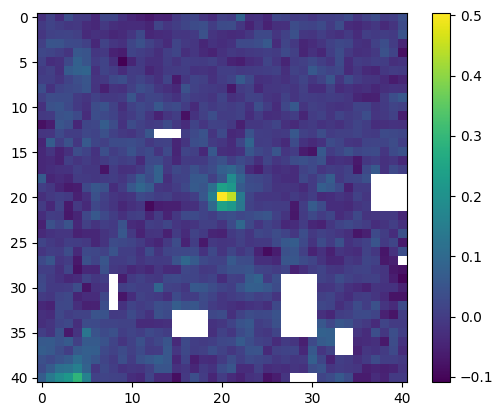

In [36]:
x = np.ma.array(clip.data, mask=mask)
x.filled(0)
plt.imshow(x)
plt.colorbar()

In [10]:
# # Instantiate dropbox token
# with open('../../secrets/dropbox_token') as token_file:
#     token = token_file.read()
#     dbx = dropbox.Dropbox(token.strip(), timeout=None)
# nisp_files = get_shared_folder_metadata(dbx_url, path='/new/', dbx=dbx)
# nisp_files = [file.name for file in nisp_files if 'IMAGE' in file.name]
# nisp_files

In [11]:
# nir_file = '../data/EUC_NIR_W-CAL-IMAGE_Y-3025-0_20241001T144757.480636Z.fits'
# with fits.open(nir_file) as hdul:
#     plt.imshow(hdul[7].data[1030:1070,1030:1070])

In [12]:
# clips = process_all('HUDF', redo_clips=True, save_clips=False)

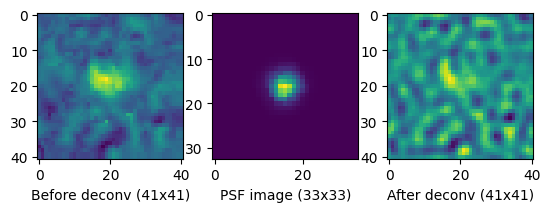

In [28]:
fig, axes = plt.subplots(1, 3)

idx = 200
test_nisp = np.pad(clips[idx][2].data, (0,1), mode='symmetric')
test_psf = clips[idx][3]

axes[0].imshow(test_nisp)
axes[0].set_xlabel("Before deconv (41x41)")
axes[1].imshow(test_psf)
axes[1].set_xlabel("PSF image (33x33)")

# Deconvolve
deconv, _ = restoration.unsupervised_wiener(test_nisp, test_psf, clip=False)
axes[2].imshow(deconv)
axes[2].set_xlabel("After deconv (41x41)")
plt.savefig("../plots/test_deconvolution.png", bbox_inches='tight')

In [13]:
# fname = '../data/NISP_PSF_HUDF_NIR_Y/euclid_hudf_nir_Y.sh'
# new_fname = fname.replace('nir_Y', 'nir_Y_psf_only')
# with open(fname, 'r') as file:
#     lines = file.readlines()
#     lines = [lines[0]]+[el for el in lines if ('PSF' in el)]
#     # lines = [lines[0]]+[el for el in lines if (('PSF' in el) and ('CATALOG' in el))]

# with open(new_fname, 'w') as file:
#     file.writelines(lines)

In [14]:
nir_psf_file = "../data/NISP_PSF_HUDF_NIR_Y/EUC_NIR_W-CAL-PSF-I_Y-3025-0_20241001T144843.454706Z.fits"

In [15]:
euclid_psf_file1 = "../data/NISP_PSF_HUDF_MER_Y/EUC_MER_CATALOG-PSF-NIR-Y_TILE102044185-B0A5EA_20241021T060047.722344Z_00.00.fits"
euclid_psf_file2 = "../data/EUC_MER_GRID-PSF-NIR-Y_TILE101541377-C9907F_20240805T181919.717517Z_00.00.fits"
euclid_psf_file3 = "../data/EUC_MER_GRID-PSF-NIR-Y_TILE102086074-9D515F_20250305T113121.621151Z_00.00.fits"

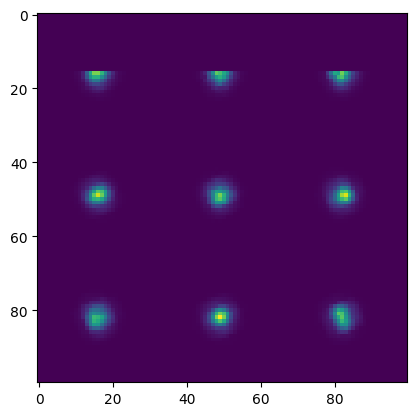

In [20]:
with fits.open(euclid_psf_file1) as hdul:
    hdr = hdul[1].header
    data = hdul[1].data
plt.imshow(data[:100,:100])

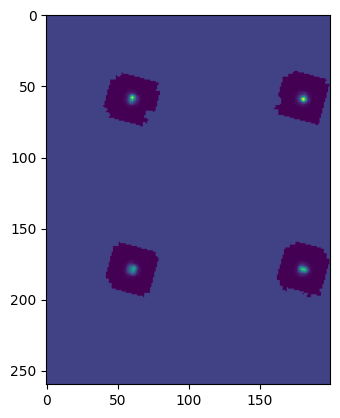

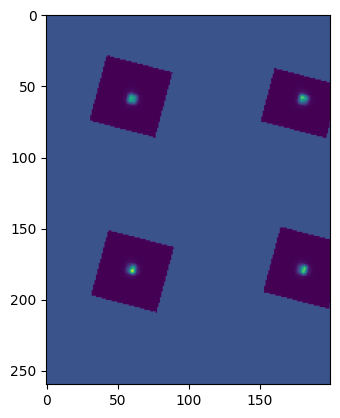

In [16]:
epsf2 = ep.EuclidPSF(euclid_psf_file2)
epsf3 = ep.EuclidPSF(euclid_psf_file3)

clip2 = epsf2.data[8581-60:8581+200,0:200].copy()
clip2[np.where(clip2==0)] = .01

clip3 = epsf3.data[5461-60:5461+200,0:200]
clip3[np.where(clip3==0)] = .01

plt.imshow(clip2)
plt.show()
plt.imshow(clip3)

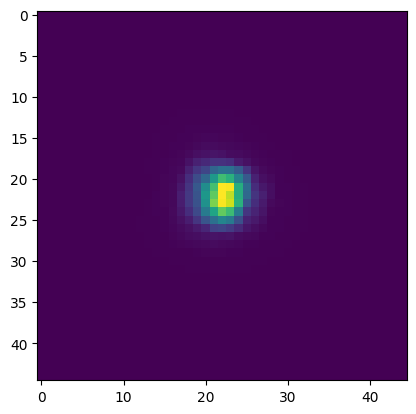

In [17]:
sc = epsf3.wcs.pixel_to_world(10000, 60000)
clip = epsf3.evaluate(sc)
plt.imshow(clip)

In [18]:
epsf3.psf_meta

,x,y,FWHM
0,61.0,5461.0,0.553758
1,61.0,5581.0,0.477654
2,61.0,5701.0,0.457173
3,61.0,5821.0,0.472023
4,61.0,5941.0,0.412781
...,...,...,...
14888,19141.0,18661.0,0.514245
14889,19141.0,18781.0,0.490489
14890,19141.0,18901.0,0.495918
14891,19141.0,19021.0,0.453218


In [19]:
epsf2.psf_meta

,x,y,FWHM
0,61.0,8581.0,0.449308
1,61.0,8701.0,0.539209
2,61.0,8821.0,0.510828
3,61.0,8941.0,0.474759
4,61.0,9061.0,0.517010
...,...,...,...
367,5581.0,10141.0,0.450341
368,5701.0,10141.0,0.468435
369,5821.0,10141.0,0.540504
370,5941.0,10141.0,0.463513


In [4]:
# psf1 = mpsf.from_file(euclid_psf_file1)

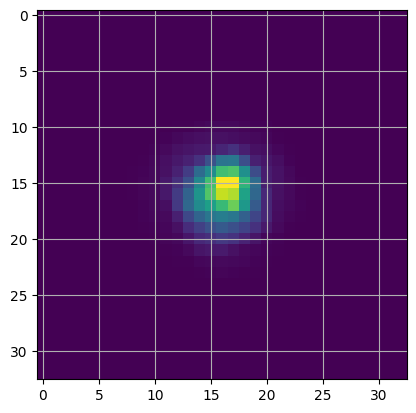

In [44]:
# psf_clip = psf1.get_closest_stamp_at_radec((52.978595, -27.723529))
# psf_clip.normalize()
# psf_data = psf_clip.get_data()
# plt.imshow(psf_data)
# plt.grid()

In [20]:
# with fits.open(euclid_psf_file1) as hdul:
#     hdr = hdul[1].header
#     hdr0 = hdul[0].header
#     wcs = WCS(hdr)
#     data = hdul[1].data
#     x_shape, y_shape = data.shape
# psf_info = Table.read(euclid_psf_file1, hdu=2).to_pandas()

# print(wcs.pixel_to_world(17, 50))
# psf_info

# # psf_size = 120 # Size of PSF image
# # stamp_size = 33 # PSF stamp size in pixel units
# # oversamp = psf_size / stamp_size
# # n_psfs = int((x_shape / psf_size) * (y_shape / psf_size))
# # x_bounds = np.arange(0, x_shape, psf_size)
# # y_bounds = np.arange(0, y_shape, psf_size)

# # data_array = np.zeros((n_psfs, psf_size, psf_size), dtype=float)
# # grid_xypos = np.zeros((n_psfs, 2), dtype=int)

# psf_info['coord'] = wcs.pixel_to_world(psf_info.y-1, psf_info.x-1)

# # i = 0
# # for x in x_bounds:
# #     for y in y_bounds:
# #         data_array[i] = data[y:y+psf_size, x:x+psf_size]
# #         grid_xypos[i] = (x+psf_size/2,y+psf_size/2)
# #         i = i+1

# # meta = {
# #     'grid_xypos': grid_xypos,
# #     'oversampling': 4,
# # }
# # data_meta = NDData(data_array, meta=meta)
# # # After all that, the oversampling factor can't be a decimal
# # # It works if I just set the oversampling to 4, no thank you
# # # !@#@#@!@3 this
# # # Ok, the WCS is wrong on the PSF images, at least the catalog ones
# hdr

In [21]:
# psf_info

In [22]:
# zeros_high = data.copy()
# zeros_high[data==0] = .05
# center = np.array([50, 17])
# clip = Cutout2D(zeros_high, center-1, 33)
# plt.imshow(clip.data)
# plt.grid()

In [23]:
# plt.imshow(zeros_high[0:120, 0:120])

In [15]:
# import euclid_psf as ep

In [16]:
# reload(ep)

<module 'euclid_psf' from '/home/eaev/superNISP/code/euclid_psf.py'>

In [17]:
# epsf = ep.EuclidPSF(euclid_psf_file1)

In [28]:
# nisp_cutouts = np.load(meta['HUDF']['matched_nisp'])

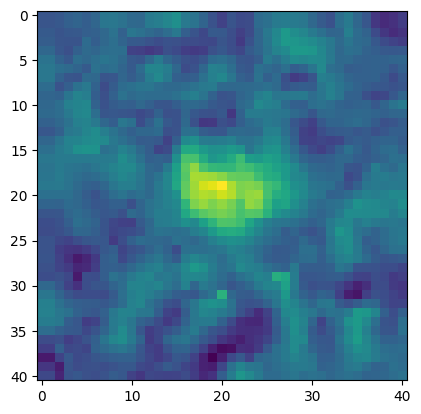

In [19]:
nisp_test = np.pad(clips[200][2].data, (1, 0), mode='symmetric')
plt.imshow(nisp_test)
psf_test = clips[200][3]

In [42]:
# psf_pt = epsf.evaluate(psf_info.coord[50])
# zoomed = scipy.ndimage.zoom(psf_pt, , order=3)
# # plt.imshow(zoomed)
# zoomed = np.pad(zoomed, 4, mode='symmetric')
# plt.imshow(zoomed)

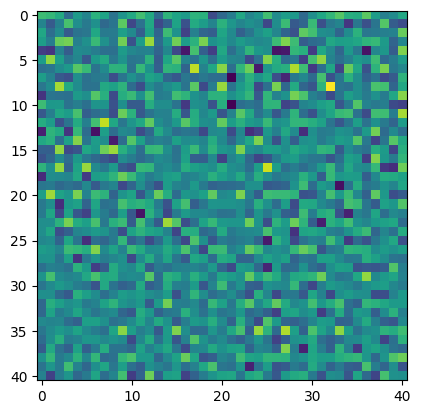

In [46]:
freq_img = np.fft.fft2(padded)
freq_img = np.fft.fftshift(freq_img)
freq_psf = np.fft.fft2(zoomed)
freq_psf = np.fft.fftshift(freq_psf)

maybe_deconv = np.fft.ifftshift(freq_img / freq_psf)
maybe_deconv = np.fft.ifftshift(np.fft.ifft2(maybe_deconv))
plt.imshow(maybe_deconv.real)

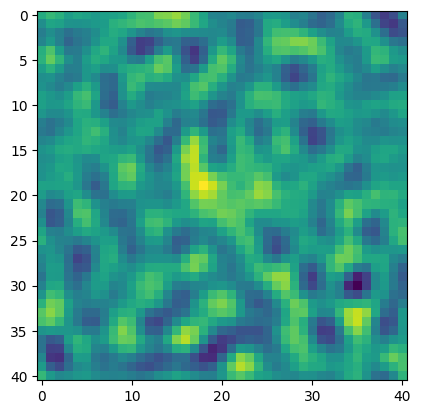

In [20]:
deconv, _ = restoration.unsupervised_wiener(nisp_test, psf_test, clip=False)
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plt.imshow(deconv)
# axes[1].imshow(padded)

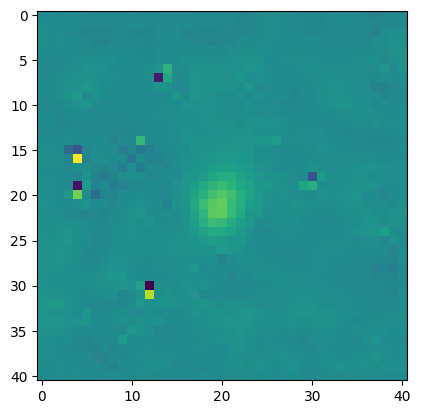

In [21]:
deconv = restoration.richardson_lucy(padded, zoomed, num_iter=30, clip=False)
plt.imshow(deconv)

In [12]:
coords = wcs.pixel_to_world(psf_info.y-1, psf_info.x-1)
psf_info.coord[0].separation(coords).degree

array([0.        , 0.00333323, 0.00666646, ..., 0.74482357, 0.74716929,
       0.7495225 ])

In [12]:
GriddedPSFModel(data_meta)

<GriddedPSFModel(flux=1., x_0=0., y_0=0.)>

In [28]:
with fits.open(euclid_psf_file2) as hdul:
    wcs = WCS(hdul[1].header)
    hdr = hdul[1].header

In [25]:
psf_info = Table.read(euclid_psf_file1, hdu=2).to_pandas()
xgrid = np.sort(np.unique(psf_info.x))

In [29]:
psf_info

,x,y,FWHM
0,61.0,61.0,0.457931
1,61.0,181.0,0.423055
2,61.0,301.0,0.490483
3,61.0,421.0,0.454768
4,61.0,541.0,0.487610
...,...,...,...
25525,19141.0,18661.0,0.445336
25526,19141.0,18781.0,0.439652
25527,19141.0,18901.0,0.481782
25528,19141.0,19021.0,0.425169
